In [32]:
%matplotlib widget

from src.MFE import *
from src.MyUlamGalerkin import *
from src.SnapCluster import *
from src.helper import *



import numpy as np
from matplotlib.cm import ScalarMappable
from scipy.linalg import eig
import matplotlib.colors as colors
from matplotlib.widgets import Slider


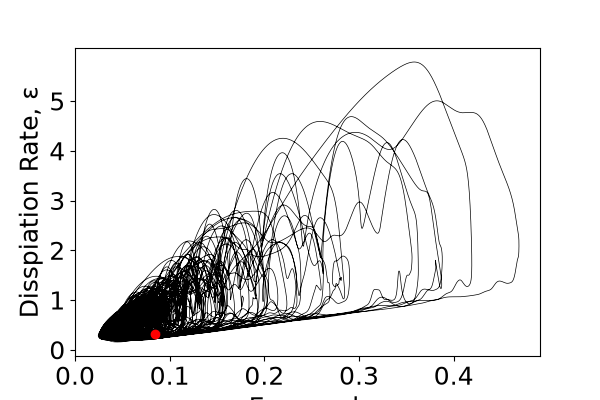

In [33]:


dt,N,istart =0.05,1010000,10000      # time-step and number of trajectory points
Re=800
Lx,Lz=1.75*np.pi,1.2*np.pi
D,E,a = MFE_Sequence(dt,N,istart,Re,Lx,Lz,a0=[1,0,0.187387,0.040112,0.047047,0,0,0.013188,0])   # generate data sequence 
#t=(np.arange(len(D))+1)*dt
DE = np.vstack((D,E)).T

figo, axo = plt.subplots(figsize=(6,4))

t=-1
axo.plot(DE[:, 1], DE[:, 0],c="black",zorder=1,linewidth=0.5)
axo.scatter(DE[t, 1], DE[t, 0],c="red",zorder=10)
#axo.set_title(f'Disspiation Rate VS Energy',fontsize=18)

axo.set_xlabel("Energy, k",fontsize=18)
axo.set_ylabel("Disspiation Rate, ε",fontsize=18)
axo.set_xticks(np.arange(0, np.max(DE[:, 1]), 0.1))
axo.set_yticks(np.arange(0, np.max(DE[:, 0]), 1))
axo.tick_params(axis='both', labelsize=18)

In [34]:
discretization_box_size = 50
A= SnapCluster(DE,Disctrize_box_size=discretization_box_size)

Time for Ulam-Galerkin Disctrization:1.498106699960772
Number of boxes: 980


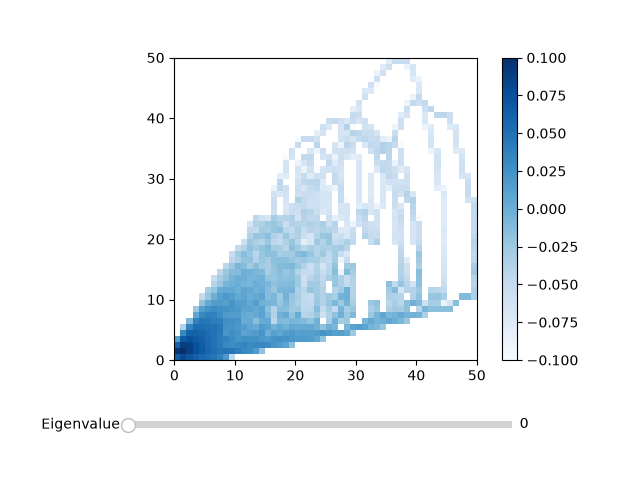

In [36]:

P=A.P
def plot_eigenvectors(Data,P,eigen_value,discretization_box_size):
    eigen_values, eigen_vectors = eig(P)
    idx = np.argsort(abs(eigen_values))[::-1]
    eigen_values_sorted = np.array(eigen_values)[idx]
    eigen_vectors_sorted = np.array(eigen_vectors)[:, idx]

    Nd=discretization_box_size
    x=DE.copy()      
    mini = np.min(x, axis=0)        #Extract minimum value of all physical variables 
    maxi = np.max(x, axis=0)        #Extract maximum value of all physical variables
    delta=(maxi+10e-12-mini)/Nd            #Discretize the state space into cells
    idx = np.floor((x - mini) / delta).astype(int)
    grid = np.zeros((Nd, Nd))

    for i in range(len(idx)):
        d_idx = idx[i, 0]
        E_idx = idx[i, 1]
        grid[d_idx,E_idx] += 1
        
    grid_eigen_vector_values = np.zeros((len(eigen_values_sorted), Nd, Nd))
    grid_log_eigen_vector_values = np.ones((len(eigen_values_sorted), Nd, Nd))*np.inf

    for k in range(len(eigen_values_sorted)):
        it = 0
        for i in range(Nd):
            for j in range(Nd):
                if grid[i, j] > 0:
                    grid_eigen_vector_values[k, i, j] = np.abs(eigen_vectors_sorted[it, k])
                    if grid_eigen_vector_values[k, i, j]> 0:
                        grid_log_eigen_vector_values[k, i, j] = np.log(grid_eigen_vector_values[k, i, j])  
                    it += 1
    #Plot
    plt.close('all')
    fig, ax = plt.subplots()
    #color bar
    data = grid_log_eigen_vector_values[eigen_value]
    mask = data!=0
    vmin_1 = np.min(data[mask])
    vmax_1 = np.max(data[mask])
    norm_1 = colors.Normalize(vmin_1, vmax_1)
    cbar = fig.colorbar(ScalarMappable(norm=norm_1, cmap='Blues'), ax=ax)


    plt.subplots_adjust(bottom=0.25)
    slider_ax = plt.axes([0.2, 0.1, 0.6, 0.03])
    slider = Slider(
        slider_ax,
        'Eigenvalue',
        0,
        len(eigen_values_sorted) - 1,
        valinit=0,
        valstep=1
    )


    color_map = np.zeros((Nd, Nd, 4))
    im = ax.imshow(
        grid_log_eigen_vector_values[eigen_value],
        cmap='Blues',
        origin='lower',
        extent=[0, Nd, 0, Nd]
    )
    def update(val):
        a = int(slider.val)
        data = grid_log_eigen_vector_values[a]
        mask = data<0
        vmin_1 = np.min(data[mask])
        vmax_1 = np.max(data[mask])
        norm_1 = colors.Normalize(vmin_1, vmax_1)


        im.set_data(data)
        im.set_norm(norm_1)
        cbar.update_normal(im)
        fig.canvas.draw_idle()

    slider.on_changed(update)
    plt.show()
plot_eigenvectors(DE,P,eigen_value=0,discretization_box_size=discretization_box_size)